In [175]:
import nltk
import string
import re

import os
import matplotlib.pyplot as plt
!pip install wordcloud
from wordcloud import WordCloud
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/mashapitel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/mashapitel/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mashapitel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/mashapitel/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
# Running Sentiment Analysis on uncleaned dataset - article descriptions with keyword 'immigration'. 

In [176]:
df_raw = pd.read_csv('immigration_articles_Raw.csv')

In [177]:
df_left = pd.read_csv('immigration_articles_Left.csv')

In [178]:
df_right = pd.read_csv('immigration_articles_Right.csv')

In [179]:
df_raw['Description']

0      The money would go toward security improvement...
1      COACHELLA VALLEY, Calif. (KESQ) – Businesses t...
2      PATTAYA, Thailand &#8211; As a legal consultan...
3      WASHINGTON (AP) — Senate Republicans have adde...
4      The Greens' manifesto in Hackney promises to '...
                             ...                        
985    President Trump claimed ICE agents handling ai...
986    They would direct the TSA to arrest anyone sus...
987    The US president called on immigration agents ...
988    Deji Elumoye in Abuja The Presidency has clari...
989    White House advisor Stephen Miller is a liar, ...
Name: Description, Length: 990, dtype: object

In [180]:
df_left['Description']

0      the money would go toward security improvement...
1      the relatives of some migrants in ice detentio...
2      president donald trumps justice department iss...
3      after drama and delay house republicans narrow...
4      the bill already passed in the us senate now m...
                             ...                        
101    democrats are quietly celebrating president do...
102    president donald trump on monday championed th...
103    as immigrant detentions and selfdeportations s...
104    tom homan president trumps chief border offici...
105    white house advisor stephen miller is a liar b...
Name: Description, Length: 106, dtype: object

In [181]:
df_right['Description']

0     the greens manifesto in hackney promises to de...
1     this monster attempted to kill her own child t...
2     whats interesting about this poll is that it p...
3     an antiice mob stormed a brooklyn hospital to ...
4     in a provocative move zia yusuf said facilitie...
                            ...                        
95    liverpool city council warned against associat...
96    liverpool city council warned against associat...
97    the staggering long lines triggered president ...
98    sheridan gorman  from yorktown heights died af...
99    in a speech last week ms rayner said plans to ...
Name: Description, Length: 100, dtype: object

In [182]:
description_raw = df_raw['Description'].to_list()

In [183]:
description_left = df_left['Description'].to_list()

In [184]:
description_right = df_right['Description'].to_list()

In [185]:
with open('descriptions_raw.txt', 'w') as f:
    f.writelines(str(description_raw))

In [186]:
with open('descriptions_left.txt', 'w') as f:
    f.writelines(str(description_left))

In [187]:
with open('descriptions_right.txt', 'w') as f:
    f.writelines(str(description_right))

In [188]:
with open('descriptions_raw.txt', 'r', encoding='utf-8') as file:
    text_data = file.read()

In [189]:
with open('descriptions_left.txt', 'r', encoding='utf-8') as file:
    left_data = file.read()

In [190]:
with open('descriptions_right.txt', 'r', encoding='utf-8') as file:
    right_data = file.read()

In [191]:
analyzer = SentimentIntensityAnalyzer()
scores = analyzer.polarity_scores(text_data)

print(scores)

{'neg': 0.106, 'neu': 0.811, 'pos': 0.083, 'compound': -1.0}


In [192]:
left_analyzer = SentimentIntensityAnalyzer()
left_scores = left_analyzer.polarity_scores(left_data)

print(left_scores)

{'neg': 0.114, 'neu': 0.794, 'pos': 0.092, 'compound': -0.9994}


In [193]:
right_analyzer = SentimentIntensityAnalyzer()
right_scores = right_analyzer.polarity_scores(right_data)

print(right_scores)

{'neg': 0.172, 'neu': 0.771, 'pos': 0.057, 'compound': -0.9999}


In [194]:
#### FREQUENCY

In [195]:
df_cleaned = pd.read_csv('immigration_articles_Cleaned.csv')

In [196]:
df_left = pd.read_csv('immigration_articles_Left.csv')

In [197]:
df_right = pd.read_csv('immigration_articles_Right.csv')

In [198]:
description_cleaned = df_cleaned['Description'].to_list()

In [199]:
description_left = df_left['Description'].to_list()

In [200]:
description_right = df_right['Description'].to_list()

In [201]:
with open('descriptions_cleaned.txt', 'w') as f:
    f.writelines(str(description_cleaned))

In [202]:
with open('descriptions_left_fq.txt', 'w') as f:
    f.writelines(str(description_left))

In [203]:
with open('descriptions_right_fq.txt', 'w') as f:
    f.writelines(str(description_right))

In [204]:
with open('descriptions_cleaned.txt', 'r', encoding='utf-8') as f:
    raw_text = f.read()
    text_no_punct = raw_text.translate(str.maketrans('', '', string.punctuation))
    text_no_numbers = re.sub(r'\d+', '', text_no_punct)
    tokens = word_tokenize(text_no_numbers)

In [205]:
with open('descriptions_left_fq.txt', 'r', encoding='utf-8') as f:
    l_raw_text = f.read()
    l_text_no_punct = l_raw_text.translate(str.maketrans('', '', string.punctuation))
    l_text_no_numbers = re.sub(r'\d+', '', l_text_no_punct)
    l_tokens = word_tokenize(l_text_no_numbers)

In [206]:
with open('descriptions_right_fq.txt', 'r', encoding='utf-8') as f:
    r_raw_text = f.read()
    r_text_no_punct = r_raw_text.translate(str.maketrans('', '', string.punctuation))
    r_text_no_numbers = re.sub(r'\d+', '', r_text_no_punct)
    r_tokens = word_tokenize(r_text_no_numbers)

In [207]:
stop_words = set(stopwords.words('english'))
filtered_tokens = [w for w in tokens if w.lower() not in stop_words]

In [208]:
l_stop_words = set(stopwords.words('english'))
l_filtered_tokens = [w for w in l_tokens if w.lower() not in l_stop_words]

In [209]:
r_stop_words = set(stopwords.words('english'))
r_filtered_tokens = [w for w in r_tokens if w.lower() not in r_stop_words]

In [210]:
fq=nltk.FreqDist(filtered_tokens)

In [211]:
l_fq=nltk.FreqDist(l_filtered_tokens)

In [212]:
r_fq=nltk.FreqDist(r_filtered_tokens)

In [213]:
for word, frequency in fq.most_common(15):
    print(u'{};{}'.format(word, frequency))

immigration;730
enforcement;283
us;246
trump;232
federal;230
first;205
ice;199
post;177
security;172
appeared;164
president;157
agents;154
customs;145
immigrants;136
said;131


In [214]:
for word, frequency in l_fq.most_common(15):
    print(u'{};{}'.format(word, frequency))

immigration;57
trump;47
president;46
trumps;34
donald;32
us;27
enforcement;25
agents;24
federal;23
ice;22
security;21
immigrants;20
said;18
court;17
would;16


In [215]:
for word, frequency in r_fq.most_common(15):
    print(u'{};{}'.format(word, frequency))

immigration;44
illegal;28
said;21
immigrant;18
enforcement;17
ice;15
federal;12
president;12
immigrants;11
yearold;11
dhs;10
agents;9
customs;9
us;9
allegedly;9


In [ ]:
### WordCloud

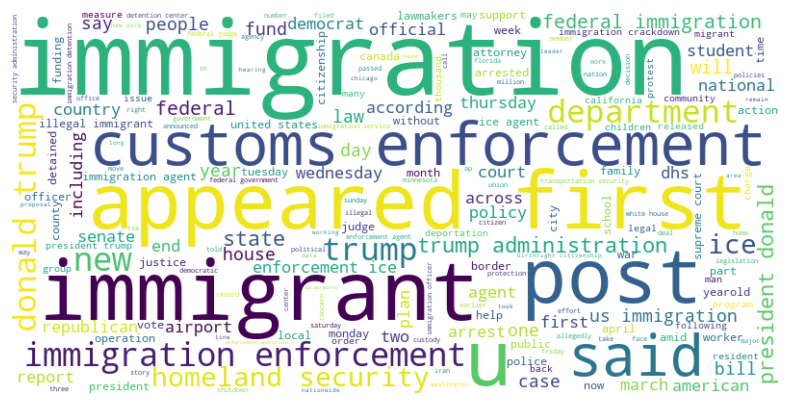

In [216]:
wordcloud_all = WordCloud(width=800, height=400, background_color='white').generate(text_no_numbers)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis("off")  # Hide the axes
plt.show()

In [219]:
wordcloud_all.to_file("wordcloud_all.png")

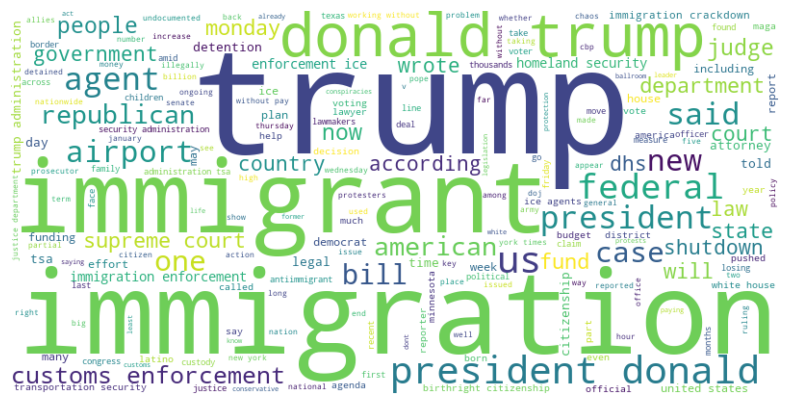

In [217]:
wordcloud_left = WordCloud(width=800, height=400, background_color='white').generate(l_text_no_numbers)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_left, interpolation='bilinear')
plt.axis("off")  # Hide the axes
plt.show()

In [220]:
wordcloud_left.to_file("wordcloud_left.png")

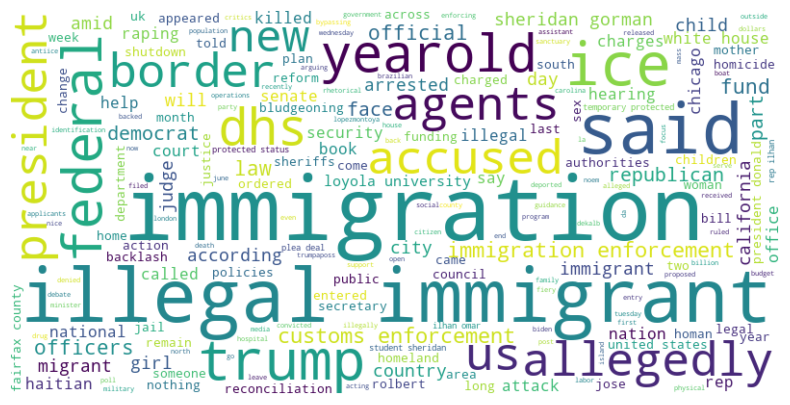

In [174]:
wordcloud_right = WordCloud(width=800, height=400, background_color='white').generate(r_text_no_numbers)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_right, interpolation='bilinear')
plt.axis("off")  # Hide the axes
plt.show()

In [218]:
wordcloud_right.to_file("wordcloud_right.png")